In [1]:
# ============================================
# Malaria Cell Segmentation Using U-Net (FINAL)
# ============================================

# =========================
# 1. IMPORTS & SETUP
# =========================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# =========================
# 2. DATA LOADING
# =========================
%pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
dataset_path = os.path.join(path, "cell_images")

parasitized = os.path.join(dataset_path, "Parasitized")
uninfected = os.path.join(dataset_path, "Uninfected")

all_images = []
for folder in [parasitized, uninfected]:
    for file in os.listdir(folder):
        all_images.append(os.path.join(folder, file))

print("Total Images:", len(all_images))

train_files, temp_files = train_test_split(all_images, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)


Note: you may need to restart the kernel to use updated packages.


c:\Users\BrainStorm\anaconda3\envs\dl_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total Images: 27560


In [3]:
# =========================
# 3. PREPROCESSING
# =========================
def apply_gradient(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    gradient = cv2.magnitude(sobelx, sobely)
    gradient = cv2.normalize(gradient, None, 0, 255, cv2.NORM_MINMAX)
    return gradient.astype(np.uint8)


def generate_mask(image):
    _, mask = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
    return mask

In [4]:
# =========================
# 4. DATASET CLASS
# =========================
class MalariaDataset(Dataset):
    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path = self.file_list[idx]

        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            image = np.zeros((128,128), dtype=np.uint8)

        image = cv2.resize(image, (128,128))

        grad = apply_gradient(image)
        image = cv2.addWeighted(image, 0.7, grad, 0.3, 0)

        mask = generate_mask(image)

        image = image / 255.0
        mask = mask / 255.0

        image = np.expand_dims(image, axis=0)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

In [5]:
# =========================
# 5. DATALOADERS
# =========================
train_loader = DataLoader(MalariaDataset(train_files), batch_size=8, shuffle=True, drop_last=True)
val_loader   = DataLoader(MalariaDataset(val_files), batch_size=8)
test_loader  = DataLoader(MalariaDataset(test_files), batch_size=8)


In [6]:
# =========================
# 6. MODEL (IMPROVED U-NET)
# =========================
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv2 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool(x1))
        x3 = self.down3(self.pool(x2))

        x = self.up1(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv2(x)

        return torch.sigmoid(self.final(x))

model = UNet().to(device)

In [7]:
# =========================
# 7. LOSS & OPTIMIZER
# =========================
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
# =========================
# 8. METRICS
# =========================
def dice_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1e-6):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)


In [9]:
# =========================
# 9. TRAINING LOOP
# =========================
num_epochs = 5
best_val_loss = float("inf")
train_losses, val_losses = [], []

for epoch in range(num_epochs):

    model.train()
    train_loss_total = 0

    for images, masks in tqdm(train_loader):
        images, masks = images.to(device), masks.to(device)

        preds = model(images)

        if preds.shape != masks.shape:
            continue

        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_total += loss.item()

    avg_train = train_loss_total / max(1, len(train_loader))
    train_losses.append(avg_train)

    model.eval()
    val_loss_total = 0
    dice_total, iou_total, count = 0, 0, 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            val_loss_total += loss.item()
            dice_total += dice_score(preds, masks).item()
            iou_total += iou_score(preds, masks).item()
            count += 1

    avg_val = val_loss_total / max(1, len(val_loader))
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1}: Train={avg_train:.4f}, Val={avg_val:.4f}, Dice={dice_total/count:.4f}, IoU={iou_total/count:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "best_model.pth")

100%|██████████| 2411/2411 [07:58<00:00,  5.04it/s]


Epoch 1: Train=0.0619, Val=0.0207, Dice=0.9523, IoU=0.9091


100%|██████████| 2411/2411 [07:36<00:00,  5.28it/s]


Epoch 2: Train=0.0166, Val=0.0118, Dice=0.9758, IoU=0.9528


100%|██████████| 2411/2411 [07:34<00:00,  5.31it/s]


Epoch 3: Train=0.0112, Val=0.0082, Dice=0.9839, IoU=0.9683


100%|██████████| 2411/2411 [07:34<00:00,  5.30it/s]


Epoch 4: Train=0.0083, Val=0.0087, Dice=0.9788, IoU=0.9585


100%|██████████| 2411/2411 [07:33<00:00,  5.32it/s]


Epoch 5: Train=0.0063, Val=0.0036, Dice=0.9944, IoU=0.9889


In [10]:
# =========================
# 10. TESTING
# =========================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_loss = 0
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        preds = model(images)
        loss = criterion(preds, masks)
        test_loss += loss.item()

print("Test Loss:", test_loss / max(1, len(test_loader)))


Test Loss: 0.0035155670910108137


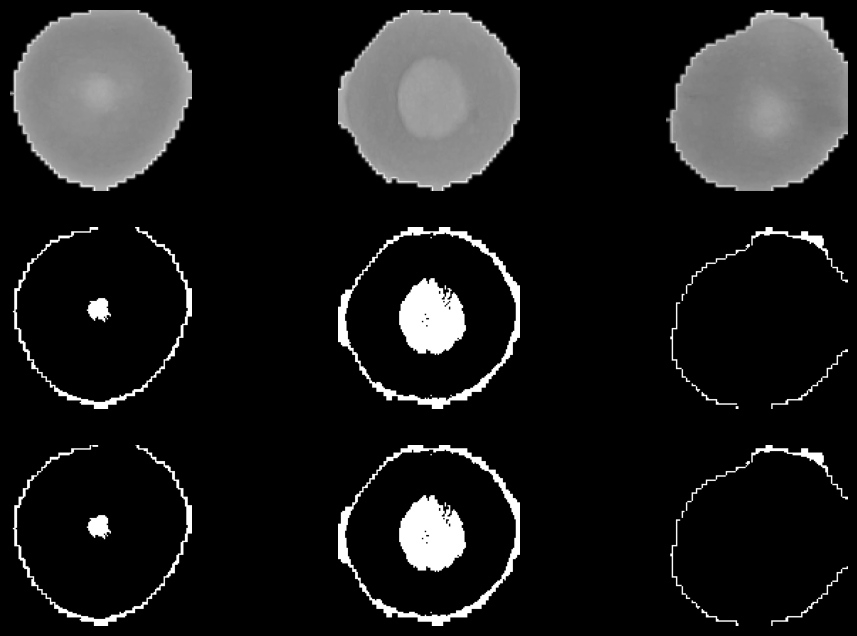

In [11]:
# =========================
# 11. VISUALIZATION
# =========================
images, masks = next(iter(test_loader))
images = images.to(device)
preds = model(images)

images = images.cpu().numpy()
masks = masks.cpu().numpy()
preds = preds.detach().cpu().numpy()

plt.figure(figsize=(12,8))
for i in range(3):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.axis("off")

    plt.subplot(3,3,i+4)
    plt.imshow(masks[i][0], cmap='gray')
    plt.axis("off")

    plt.subplot(3,3,i+7)
    plt.imshow(preds[i][0] > 0.5, cmap='gray')
    plt.axis("off")

plt.show()

In [12]:
# =========================
# 12. INFERENCE FUNCTION
# =========================
def predict_image(model, image_path):
    model.eval()

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128,128))

    grad = apply_gradient(image)
    image = cv2.addWeighted(image, 0.7, grad, 0.3, 0)

    image = image / 255.0
    image = np.expand_dims(image, axis=(0,1))

    image = torch.tensor(image, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(image)

    return pred.cpu().numpy()[0][0]
